1. Import Libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. API Data Collection

2A. News API Data Collection

In [81]:
import requests
import pandas as pd
from datetime import datetime

In [82]:
NEWS_API_KEY = "065269513e0a49b3b518b4c80a9bf375"

topics = ["AI music", "sustainable fashion", "mindfulness", "digital art"]

articles = []

for topic in topics:
    url = "https://newsapi.org/v2/everything"
    
    params = {
        "q": topic,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": 20,
        "apiKey": NEWS_API_KEY
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    for item in data.get("articles", []):
        articles.append({
            "date": item["publishedAt"][:10],
            "source": "NewsAPI",
            "topic": topic,
            "text": str(item.get("title", "")) + " " + str(item.get("description", "")),
            "engagement": len(item.get("title", "")) / 10
        })

df = pd.DataFrame(articles)

df.head()

,date,source,topic,text,engagement
0,2026-04-27,NewsAPI,AI music,NCT's Taeyong roars back with self-produced al...,7.4
1,2026-04-27,NewsAPI,AI music,Is 'Pride and Prejudice: Dino Time!' real 'los...,5.4
2,2026-04-27,NewsAPI,AI music,Real Estate Branding: How to Stand Out in a Sa...,6.0
3,2026-04-27,NewsAPI,AI music,The 19th Beijing Auto show Kicks Off: OMODA&JA...,7.2
4,2026-04-27,NewsAPI,AI music,"EDM Gaming Music X - Rhythm, Arcade, Racing, E...",8.0


2B. Spotify API Data Collection 

In [83]:
import requests
import pandas as pd
from datetime import datetime

SPOTIFY_CLIENT_ID = "7431b760f1a94758a96c9c3695478323"
SPOTIFY_CLIENT_SECRET = "3fa46fa0bbfe4ced91052e966f3a2aa7"

auth_url = "https://accounts.spotify.com/api/token"

auth_response = requests.post(
    auth_url,
    data={"grant_type": "client_credentials"},
    auth=(SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)
)

access_token = auth_response.json()["access_token"]

access_token[:10]

'BQANsiQv0-'

In [84]:
topics = ["AI music", "meditation", "sustainable fashion", "digital art"]

spotify_rows = []

headers = {
    "Authorization": f"Bearer {access_token}"
}

for topic in topics:
    url = "https://api.spotify.com/v1/search"
    
    params = {
        "q": topic,
        "type": "track",
        "limit": 10
    }

    response = requests.get(url, headers=headers, params=params)
    data = response.json()

    if "tracks" not in data:
        print("Spotify error for topic:", topic)
        print(data)
        continue

    for item in data["tracks"]["items"]:
        spotify_rows.append({
            "date": datetime.today().date(),
            "source": "Spotify",
            "topic": topic,
            "text": item["name"] + " by " + item["artists"][0]["name"],
            "engagement": item.get("popularity", 50)
        })

spotify_df = pd.DataFrame(spotify_rows)

spotify_df.head()

,date,source,topic,text,engagement
0,2026-04-27,Spotify,AI music,BLACK WATER DAMNED by BURNIN' BRIDGES Ai Music,50
1,2026-04-27,Spotify,AI music,I Ain't Gay by Biscuit Beats,50
2,2026-04-27,Spotify,AI music,Helicopter Dick by Beats By AI,50
3,2026-04-27,Spotify,AI music,Ai music is cooked by unforgivend,50
4,2026-04-27,Spotify,AI music,I Ain't Worried by OneRepublic,50


2C. Reddit Public JSON Data Collection

In [85]:
import requests
import pandas as pd
from datetime import datetime
import time

subreddits = ["technology", "music", "fashion", "worldnews", "datascience"]

reddit_rows = []

headers = {
    "User-Agent": "TrendCast academic capstone project by u/DelusionalCat12"
}

for subreddit in subreddits:
    url = f"https://www.reddit.com/r/{subreddit}/hot.json"
    
    params = {
        "limit": 20
    }
    
    response = requests.get(url, headers=headers, params=params)
    
    if response.status_code == 200:
        data = response.json()
        
        for post in data["data"]["children"]:
            p = post["data"]
            
            reddit_rows.append({
                "date": datetime.fromtimestamp(p["created_utc"]).date(),
                "source": "Reddit",
                "topic": subreddit,
                "text": str(p.get("title", "")) + " " + str(p.get("selftext", "")),
                "engagement": p.get("score", 0) + p.get("num_comments", 0)
            })
    else:
        print("Failed:", subreddit, response.status_code)
    
    time.sleep(1)

reddit_df = pd.DataFrame(reddit_rows)

reddit_df.head()

,date,source,topic,text,engagement
0,2026-04-27,Reddit,technology,Claude-powered AI coding agent deletes entire ...,30390
1,2026-04-27,Reddit,technology,Enterprise Tried Pinning Bogus $7K Bill on Ren...,1725
2,2026-04-27,Reddit,technology,Google DeepMind Paper Argues LLMs Will Never B...,873
3,2026-04-27,Reddit,technology,Taylor Swift Moves to Trademark Her Voice and ...,1154
4,2026-04-27,Reddit,technology,"Apple, Google crushed California bill that hel...",2284


combine News + Spotify into one dataframe

In [86]:
combined_df = pd.concat([df, spotify_df, reddit_df], ignore_index=True)

combined_df.head()

,date,source,topic,text,engagement
0,2026-04-27,NewsAPI,AI music,NCT's Taeyong roars back with self-produced al...,7.4
1,2026-04-27,NewsAPI,AI music,Is 'Pride and Prejudice: Dino Time!' real 'los...,5.4
2,2026-04-27,NewsAPI,AI music,Real Estate Branding: How to Stand Out in a Sa...,6.0
3,2026-04-27,NewsAPI,AI music,The 19th Beijing Auto show Kicks Off: OMODA&JA...,7.2
4,2026-04-27,NewsAPI,AI music,"EDM Gaming Music X - Rhythm, Arcade, Racing, E...",8.0


In [87]:
combined_df["source"].value_counts()

source
Reddit     100
NewsAPI     78
Spotify     40
Name: count, dtype: int64

3. Clean Text

In [88]:
import re

df = combined_df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["source", "topic", "text", "clean_text"]].head()

,source,topic,text,clean_text
0,NewsAPI,AI music,NCT's Taeyong roars back with self-produced al...,ncts taeyong roars back with selfproduced albu...
1,NewsAPI,AI music,Is 'Pride and Prejudice: Dino Time!' real 'los...,is pride and prejudice dino time real lost fil...
2,NewsAPI,AI music,Real Estate Branding: How to Stand Out in a Sa...,real estate branding how to stand out in a sat...
3,NewsAPI,AI music,The 19th Beijing Auto show Kicks Off: OMODA&JA...,the th beijing auto show kicks off omodajaecoo...
4,NewsAPI,AI music,"EDM Gaming Music X - Rhythm, Arcade, Racing, E...",edm gaming music x rhythm arcade racing electr...


4. Sentiment Analysis

In [89]:
!pip install textblob
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df["sentiment"] = df["clean_text"].apply(get_sentiment)

df[["source", "topic", "clean_text", "sentiment"]].head()

,source,topic,clean_text,sentiment
0,NewsAPI,AI music,ncts taeyong roars back with selfproduced albu...,0.162500
1,NewsAPI,AI music,is pride and prejudice dino time real lost fil...,0.100000
2,NewsAPI,AI music,real estate branding how to stand out in a sat...,0.080000
3,NewsAPI,AI music,the th beijing auto show kicks off omodajaecoo...,0.125000
4,NewsAPI,AI music,edm gaming music x rhythm arcade racing electr...,-0.233333


5. Trend Score

In [90]:
df.columns

Index(['date', 'source', 'topic', 'text', 'engagement', 'clean_text',
       'sentiment'],
      dtype='object')

In [91]:
df["engagement_norm"] = df["engagement"] / df["engagement"].max()

trend_df = df.groupby(["topic", "source"]).agg(
    mention_count=("text", "count"),
    avg_engagement=("engagement_norm", "mean"),
    avg_sentiment=("sentiment", "mean")
).reset_index()

trend_df["mention_score"] = trend_df["mention_count"] / trend_df["mention_count"].max()
trend_df["engagement_score"] = trend_df["avg_engagement"] / trend_df["avg_engagement"].max()
trend_df["sentiment_score"] = (trend_df["avg_sentiment"] + 1) / 2

trend_df["trend_score"] = (
    0.4 * trend_df["mention_score"] +
    0.4 * trend_df["engagement_score"] +
    0.2 * trend_df["sentiment_score"]
)

trend_df.sort_values("trend_score", ascending=False)

,topic,source,mention_count,avg_engagement,avg_sentiment,mention_score,engagement_score,sentiment_score,trend_score
12,worldnews,Reddit,20,0.160836,0.008862,1.0,1.000000,0.504431,0.900886
11,technology,Reddit,20,0.128922,0.004580,1.0,0.801577,0.502290,0.821089
8,music,Reddit,20,0.031323,-0.048032,1.0,0.194750,0.475984,0.573097
5,fashion,Reddit,20,0.009627,0.059569,1.0,0.059853,0.529785,0.529898
9,sustainable fashion,NewsAPI,20,0.000296,0.223378,1.0,0.001841,0.611689,0.523074
2,datascience,Reddit,20,0.003309,0.108100,1.0,0.020572,0.554050,0.519039
3,digital art,NewsAPI,20,0.000264,0.175809,1.0,0.001640,0.587904,0.518237
7,mindfulness,NewsAPI,20,0.000261,0.101231,1.0,0.001623,0.550615,0.510772
0,AI music,NewsAPI,18,0.000236,0.076196,0.9,0.001470,0.538098,0.468208
4,digital art,Spotify,10,0.001645,0.080000,0.5,0.010230,0.540000,0.312092


In [92]:
final_trends = trend_df.groupby("topic").agg({
    "mention_count": "sum",
    "avg_engagement": "mean",
    "avg_sentiment": "mean"
}).reset_index()

final_trends["mention_score"] = final_trends["mention_count"] / final_trends["mention_count"].max()
final_trends["engagement_score"] = final_trends["avg_engagement"] / final_trends["avg_engagement"].max()
final_trends["sentiment_score"] = (final_trends["avg_sentiment"] + 1) / 2

final_trends["trend_score"] = (
    0.4 * final_trends["mention_score"] +
    0.4 * final_trends["engagement_score"] +
    0.2 * final_trends["sentiment_score"]
)

final_trends.sort_values("trend_score", ascending=False)

,topic,mention_count,avg_engagement,avg_sentiment,mention_score,engagement_score,sentiment_score,trend_score
9,worldnews,20,0.160836,0.008862,0.666667,1.000000,0.504431,0.767553
8,technology,20,0.128922,0.004580,0.666667,0.801577,0.502290,0.687756
7,sustainable fashion,30,0.000971,0.151689,1.000000,0.006035,0.575845,0.517583
2,digital art,30,0.000955,0.127904,1.000000,0.005935,0.563952,0.515164
0,AI music,28,0.000941,0.020598,0.933333,0.005850,0.510299,0.477733
6,music,20,0.031323,-0.048032,0.666667,0.194750,0.475984,0.439764
3,fashion,20,0.009627,0.059569,0.666667,0.059853,0.529785,0.396565
1,datascience,20,0.003309,0.108100,0.666667,0.020572,0.554050,0.385705
5,mindfulness,20,0.000261,0.101231,0.666667,0.001623,0.550615,0.377439
4,meditation,10,0.001645,0.000000,0.333333,0.010230,0.500000,0.237425


6. Novelty Score (KL Divergence)

In [95]:
topic_counts = final_trends["mention_count"]
topic_distribution = topic_counts / topic_counts.sum()

# assume equal baseline distribution
baseline = np.ones(len(topic_distribution)) / len(topic_distribution)

final_trends["novelty_score"] = topic_distribution * np.log(
    (topic_distribution + 1e-10) / (baseline + 1e-10)
)

# normalize to 0–1
final_trends["novelty_score_norm"] = (
    final_trends["novelty_score"] - final_trends["novelty_score"].min()
) / (
    final_trends["novelty_score"].max() - final_trends["novelty_score"].min()
)

final_trends.sort_values("novelty_score_norm", ascending=False)

final_trends["final_score_with_novelty"] = (
    0.30 * final_trends["mention_score"] +
    0.30 * final_trends["engagement_score"] +
    0.20 * final_trends["sentiment_score"] +
    0.20 * final_trends["novelty_score_norm"]
)

final_trends.sort_values("final_score_with_novelty", ascending=False)

,topic,mention_count,avg_engagement,avg_sentiment,mention_score,engagement_score,sentiment_score,trend_score,novelty_score,novelty_score_norm,final_score_with_novelty
9,worldnews,20,0.160836,0.008862,0.666667,1.000000,0.504431,0.767553,-0.007906,0.349398,0.670766
7,sustainable fashion,30,0.000971,0.151689,1.000000,0.006035,0.575845,0.517583,0.043939,1.000000,0.616980
2,digital art,30,0.000955,0.127904,1.000000,0.005935,0.563952,0.515164,0.043939,1.000000,0.614571
8,technology,20,0.128922,0.004580,0.666667,0.801577,0.502290,0.687756,-0.007906,0.349398,0.610811
0,AI music,28,0.000941,0.020598,0.933333,0.005850,0.510299,0.477733,0.032148,0.852038,0.554222
6,music,20,0.031323,-0.048032,0.666667,0.194750,0.475984,0.439764,-0.007906,0.349398,0.423501
3,fashion,20,0.009627,0.059569,0.666667,0.059853,0.529785,0.396565,-0.007906,0.349398,0.393792
1,datascience,20,0.003309,0.108100,0.666667,0.020572,0.554050,0.385705,-0.007906,0.349398,0.386861
5,mindfulness,20,0.000261,0.101231,0.666667,0.001623,0.550615,0.377439,-0.007906,0.349398,0.380490
4,meditation,10,0.001645,0.000000,0.333333,0.010230,0.500000,0.237425,-0.035749,0.000000,0.203069


7. Visualization 

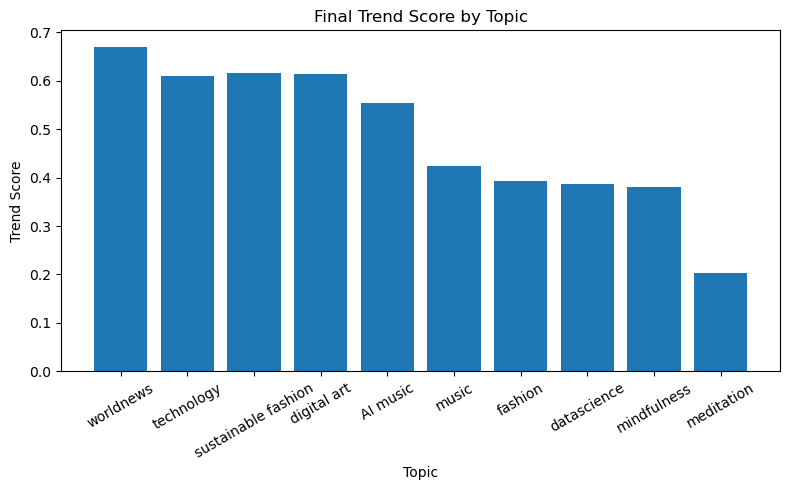

In [96]:
top_trends = final_trends.sort_values("trend_score", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(top_trends["topic"], top_trends["final_score_with_novelty"])
plt.title("Final Trend Score by Topic")
plt.xlabel("Topic")
plt.ylabel("Trend Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()